<a href="https://colab.research.google.com/github/RinaSyazana/sign-language-recognition-model/blob/main/CNN_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FYP: BIM Sign Language CNN Training (Optimized Version)
This notebook has been heavily optimized to prevent Google Colab Out-of-Memory (OOM) crashes and GPU driver failures.


## 1. Setup & Mount Google Drive


In [1]:
from google.colab import drive
import os
import zipfile
import gc

# Mount Google Drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/processed_dataset.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")


Mounted at /content/drive
Extracting dataset...
Extraction complete!


## 2. Import Libraries & Enable GPU Memory Optimizations


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# OPTIMIZATION 1: Enable Mixed Precision (Uses half the GPU memory and trains much faster on T4 GPUs)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# OPTIMIZATION 2: Lower Batch Size to prevent RAM crashes
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
DATA_DIR = '/content/dataset/processed_dataset'

# Load Training Data (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load Validation Data (20%)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Classes ({NUM_CLASSES}):", class_names)

# OPTIMIZATION 3: Do NOT use .cache() to save System RAM. Only use prefetch.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)



Found 22500 files belonging to 25 classes.
Using 18000 files for training.
Found 22500 files belonging to 25 classes.
Using 4500 files for validation.
Classes (25): ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'AWAK', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'MAAF', 'MAKAN', 'MINUM', 'SALAH', 'SAYA', 'TOLONG']


## 3. Model 1: Custom CNN


In [3]:
# OPTIMIZATION 4: Clear lingering memory before building a new model
tf.keras.backend.clear_session()
gc.collect()

def build_custom_cnn():
    model = models.Sequential([
        tf.keras.Input(shape=(224, 224, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        # Mixed precision requires the last layer to be float32 for numerical stability
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_custom_cnn()
print("Training Custom CNN...")
cnn_history = cnn_model.fit(train_dataset, validation_data=val_dataset, epochs=10)



Training Custom CNN...
Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.8559 - loss: 0.5093 - val_accuracy: 0.9787 - val_loss: 0.0716
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9631 - loss: 0.1232 - val_accuracy: 0.9889 - val_loss: 0.0429
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9756 - loss: 0.0836 - val_accuracy: 0.9876 - val_loss: 0.0502
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9828 - loss: 0.0585 - val_accuracy: 0.9842 - val_loss: 0.0631
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9853 - loss: 0.0478 - val_accuracy: 0.9911 - val_loss: 0.0331
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9886 - loss: 0.0406 - val_accuracy: 0.9829 - val_loss: 0.0614
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9906 - loss: 0.0365 - val_accuracy: 0.9911 - val_loss: 0.0334
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/st

## 4. Model 2: MobileNetV2 (Transfer Learning)


In [4]:
# Clear memory from the previous model training
tf.keras.backend.clear_session()
gc.collect()

def build_mobilenet():
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    model = models.Sequential([
        layers.Rescaling(1./127.5, offset=-1, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

mn_model = build_mobilenet()
print("Training MobileNetV2...")
mn_history = mn_model.fit(train_dataset, validation_data=val_dataset, epochs=10)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training MobileNetV2...
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 64s 36ms/step - accuracy: 0.8342 - loss: 0.5777 - val_accuracy: 0.9784 - val_loss: 0.1017
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9526 - loss: 0.1560 - val_accuracy: 0.9844 - val_loss: 0.0557
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9656 - loss: 0.1120 - val_accuracy: 0.9891 - val_loss: 0.0434
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9713 - loss: 0.0874 - val_accuracy: 0.9907 - val_loss: 0.0367
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9738 - loss: 0.0795 - val_accuracy: 0.9876 - val_loss: 0.0499
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9767 - loss: 0.0675 - val_accuracy: 0.9913 - val_loss: 0.0322
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9749 - loss: 0.0725 - val_accuracy: 0.9913 - val_loss: 0.0304
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9802 - loss: 0.06

## 5. Model 3: ResNet50 (Transfer Learning)


In [5]:
# Clear memory
tf.keras.backend.clear_session()
gc.collect()

def build_resnet():
    base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

rn_model = build_resnet()
print("Training ResNet50...")
rn_history = rn_model.fit(train_dataset, validation_data=val_dataset, epochs=10)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training ResNet50...
Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 95s 69ms/step - accuracy: 0.0512 - loss: 3.1525 - val_accuracy: 0.1002 - val_loss: 3.0068
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 74s 63ms/step - accuracy: 0.0760 - loss: 3.0283 - val_accuracy: 0.1369 - val_loss: 2.8933
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 75s 62ms/step - accuracy: 0.0842 - loss: 2.9790 - val_accuracy: 0.1438 - val_loss: 2.8598
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 74s 63ms/step - accuracy: 0.0987 - loss: 2.9538 - val_accuracy: 0.1922 - val_loss: 2.7787
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 73s 62ms/step - accuracy: 0.0986 - loss: 2.9333 - val_accuracy: 0.1882 - val_loss: 2.7500
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 73s 62ms/step - accuracy: 0.1054 - loss: 2.9137 - val_accuracy: 0.1993 - val_loss: 2.6945
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 75s 62ms/step - accuracy: 0.1054 - loss: 2.9102 - val_accuracy: 0.2438 - val_loss: 2.6710
Epoc

## 6. Evaluation


Custom CNN Graphs:


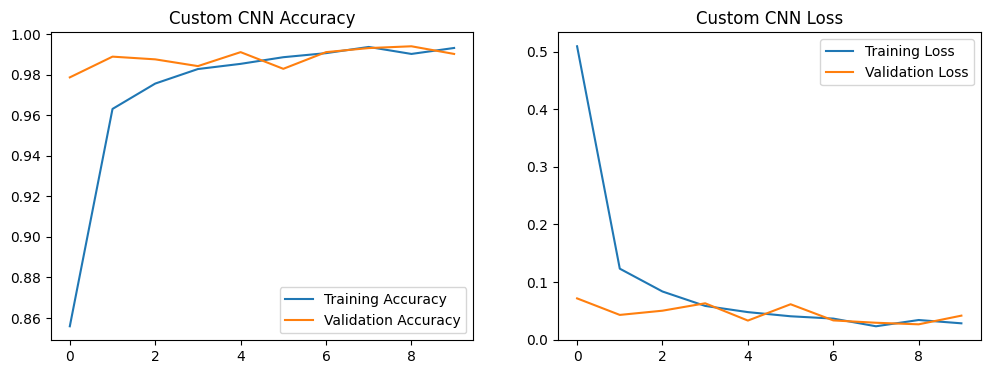

MobileNetV2 Graphs:


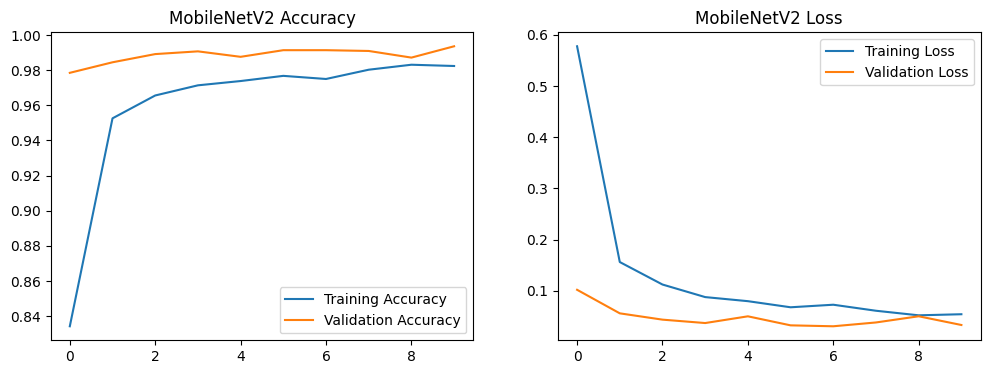

ResNet50 Graphs:


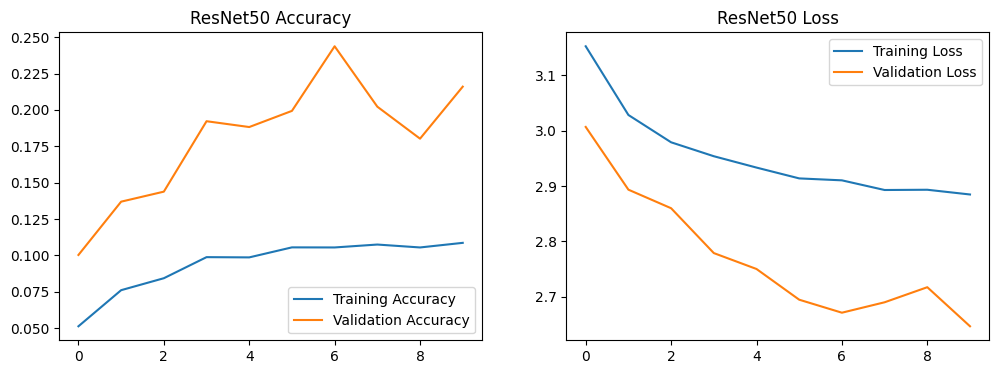

In [6]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} Loss')
    plt.show()

print("Custom CNN Graphs:")
plot_history(cnn_history, "Custom CNN")
print("MobileNetV2 Graphs:")
plot_history(mn_history, "MobileNetV2")
print("ResNet50 Graphs:")
plot_history(rn_history, "ResNet50")



In [8]:
print("Evaluating Custom CNN on Validation Set...")

y_true_cnn = []
y_pred_probs_cnn = []

for images, labels in val_dataset:
    y_true_cnn.extend(labels.numpy())
    preds_cnn = cnn_model.predict(images, verbose=0)
    y_pred_probs_cnn.extend(preds_cnn)

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

print("\nClassification Report for Custom CNN:")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

Evaluating Custom CNN on Validation Set...

Classification Report for Custom CNN:
              precision    recall  f1-score   support

           1       0.96      0.98      0.97       156
           2       0.99      1.00      1.00       175
           3       1.00      1.00      1.00       169
           4       0.97      0.98      0.97       173
           5       1.00      1.00      1.00       205
           6       0.97      0.98      0.98       182
           7       0.98      0.99      0.98       163
           8       0.99      0.98      0.99       180
           9       0.99      0.98      0.99       181
           A       1.00      0.99      0.99       165
        AWAK       0.98      0.99      0.99       183
           B       0.97      0.99      0.98       183
           C       1.00      0.99      1.00       166
           D       1.00      0.98      0.99       173
           E       0.99      0.99      0.99       178
           F       1.00      0.98      0.99       185

In [7]:
print("Evaluating MobileNetV2 on Validation Set...")
y_true = []
y_pred_probs = []

for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    preds = mn_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))



Evaluating MobileNetV2 on Validation Set...

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       156
           2       0.99      0.99      0.99       175
           3       0.99      0.99      0.99       169
           4       0.99      0.98      0.99       173
           5       1.00      1.00      1.00       205
           6       0.97      1.00      0.99       182
           7       1.00      0.98      0.99       163
           8       0.99      1.00      1.00       180
           9       0.98      0.99      0.98       181
           A       1.00      1.00      1.00       165
        AWAK       0.99      0.98      0.99       183
           B       0.98      0.99      0.99       183
           C       1.00      1.00      1.00       166
           D       1.00      0.99      0.99       173
           E       0.99      0.99      0.99       178
           F       0.99      0.97      0.98       185
           G 

In [9]:
print("Evaluating ResNet50 on Validation Set...")

y_true_rn = []
y_pred_probs_rn = []

for images, labels in val_dataset:
    y_true_rn.extend(labels.numpy())
    preds_rn = rn_model.predict(images, verbose=0)
    y_pred_probs_rn.extend(preds_rn)

y_true_rn = np.array(y_true_rn)
y_pred_rn = np.argmax(y_pred_probs_rn, axis=1)

print("\nClassification Report for ResNet50:")
print(classification_report(y_true_rn, y_pred_rn, target_names=class_names))

Evaluating ResNet50 on Validation Set...

Classification Report for ResNet50:
              precision    recall  f1-score   support

           1       0.15      0.13      0.14       156
           2       0.21      0.32      0.25       175
           3       0.00      0.00      0.00       169
           4       0.17      0.08      0.11       173
           5       0.48      0.58      0.53       205
           6       0.00      0.00      0.00       182
           7       0.12      0.55      0.19       163
           8       0.00      0.00      0.00       180
           9       0.00      0.00      0.00       181
           A       0.27      0.37      0.31       165
        AWAK       0.09      0.09      0.09       183
           B       0.36      0.07      0.12       183
           C       0.01      0.01      0.01       166
           D       0.45      0.80      0.57       173
           E       0.21      0.17      0.19       178
           F       0.00      0.00      0.00       185
   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6.1 Confusable Gestures Analysis (Confusion Matrix)
Let's visualize the confusion matrix for the MobileNetV2 model to see which signs are most frequently confused.

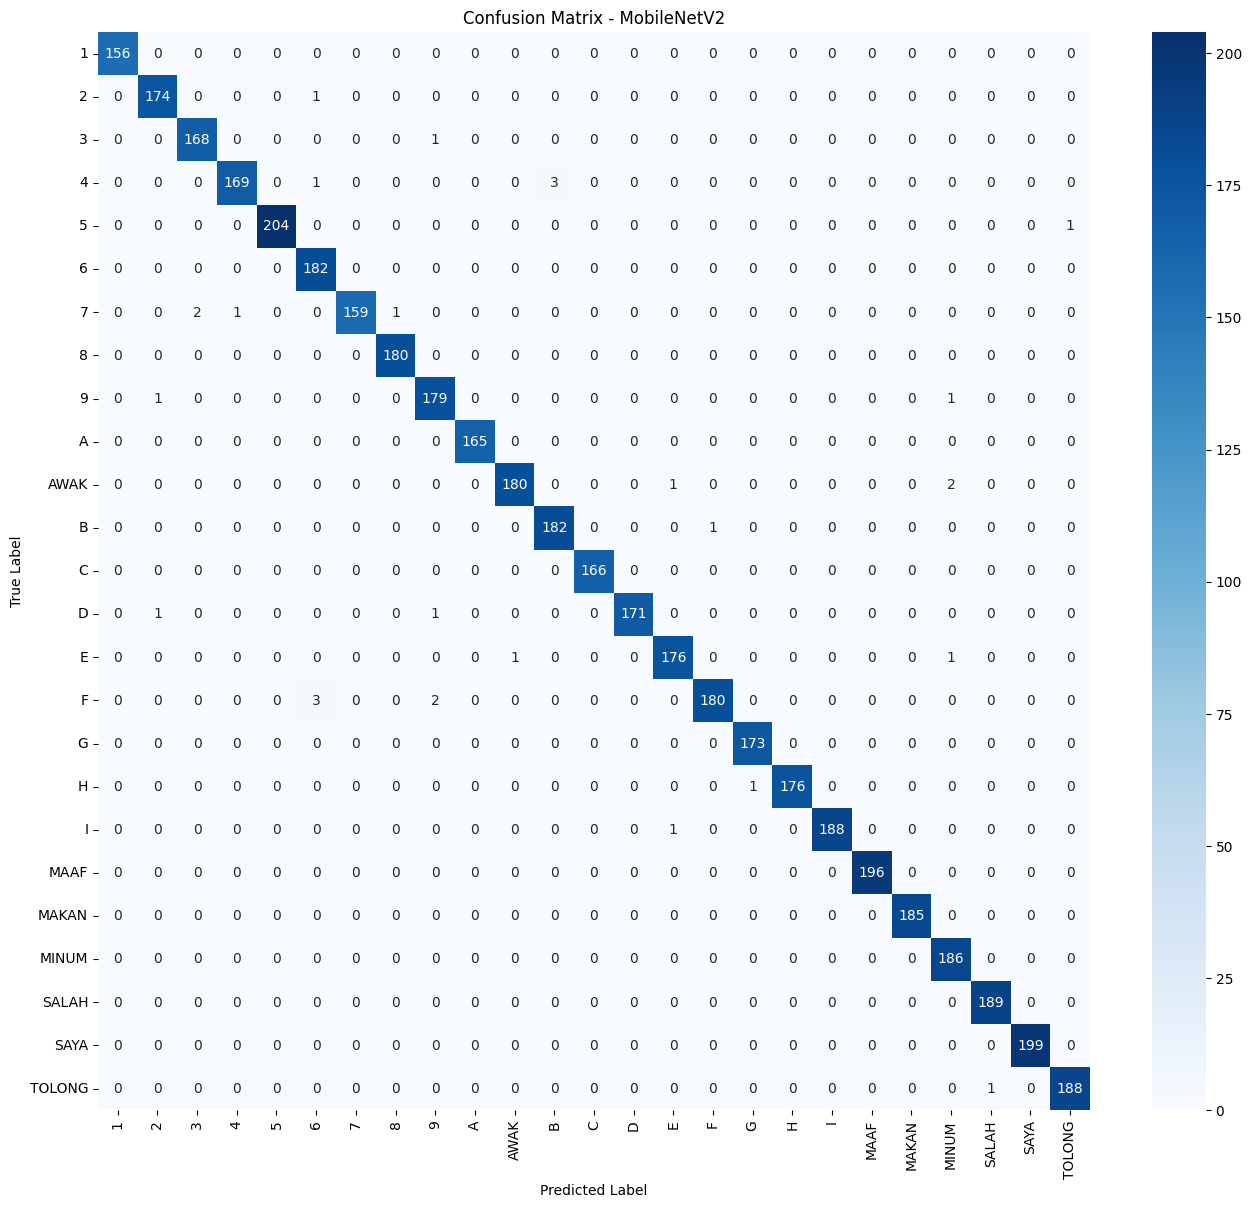

In [11]:
import seaborn as sns

# Compute the confusion matrix for MobileNetV2
cm = confusion_matrix(y_true, y_pred)

# Plotting the heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MobileNetV2')
plt.show()

**How to read this:**
* **Diagonal cells:** Show correct classifications.
* **Off-diagonal cells:** If you see numbers in cells like (True: F, Predicted: 6), it confirms the model is biased toward confusing those specific visually similar gestures.

### 6.2 Model Fit Diagnostic
Use this guide to interpret the graphs generated earlier:

1.  **Overfitting**: The Training Loss continues to decrease, but the Validation Loss starts to increase (or stays high). This means the model is memorizing the training images but cannot generalize to new ones.
2.  **Underfitting**: The Training Accuracy remains low even after many epochs. This usually means the model is too simple or needs more training time.
3.  **Good Fit**: Both Training and Validation accuracy increase together and plateau at a similar high level. The gap between them should be small.

In [12]:
# Summary Diagnostic
print("--- Final Diagnostic ---")
def check_fit(history, name):
    final_train = history.history['accuracy'][-1]
    final_val = history.history['val_accuracy'][-1]
    gap = abs(final_train - final_val)

    print(f"\nModel: {name}")
    print(f"Training Acc: {final_train:.4f}, Val Acc: {final_val:.4f}")

    if final_train > 0.90 and gap < 0.05:
        print("Result: Good Fit ")
    elif final_train > final_val + 0.10:
        print("Result: Potential Overfitting ")
    elif final_train < 0.50:
        print("Result: Underfitting ")
    else:
        print("Result: Balanced/Improving")

check_fit(cnn_history, "Custom CNN")
check_fit(mn_history, "MobileNetV2")
check_fit(rn_history, "ResNet50")

--- Final Diagnostic ---

Model: Custom CNN
Training Acc: 0.9932, Val Acc: 0.9902
Result: Good Fit 

Model: MobileNetV2
Training Acc: 0.9823, Val Acc: 0.9936
Result: Good Fit 

Model: ResNet50
Training Acc: 0.1086, Val Acc: 0.2160
Result: Underfitting 


Once these reports are generated, you can compare the overall accuracy, macro avg, and weighted avg F1-scores to definitively determine which model performed the best on your validation set.

## 7. Save Best Model


In [10]:
import json

# 1. Save the best model (MobileNetV2)
model_path = '/content/drive/MyDrive/best_model.keras'
mn_model.save(model_path)
print(f"Model successfully saved to {model_path}!")

# 2. Also save the class names mapping for React frontend (Phase 5)
labels_path = '/content/drive/MyDrive/class_names.json'
with open(labels_path, 'w') as f:
    json.dump(class_names, f)
print(f"Class names successfully saved to {labels_path}!")

Model successfully saved to /content/drive/MyDrive/best_model.keras!
Class names successfully saved to /content/drive/MyDrive/class_names.json!
